TOPIC: TIMESERIES SALES FORECASTING FOR A RETAIL CHAIN

The first step is to import the libraries such as pandas and numpy for data handling, matplotlib and seaborn for data visualization, seasonal decompose for timeseries decomposition of data, plot_acf and plot_pacf for finding p and q order for ARIMA and SARIMA model, adfuller for stationarity test, all the models and sklearn metrics for model evaluation.

STEP 1: IMPORTING THE LIBRARIES

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

Importing plotly failed. Interactive plots will not work.


STEP 2: LOADING DATASET

In [2]:
df = pd.read_csv("C:\TY Sem 5 project\Dataset\Sample_superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
print("Metadata information of the dataset:")
df.info()

Metadata information of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          

In [4]:
print("Count of rows and columns in the dataset:")
df.shape

Count of rows and columns in the dataset:


(9800, 18)

STEP 3: DATA CLEANING AND PREPROCESSING

In [5]:
df.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [6]:
df.duplicated().sum()

0

For timeseries sales forecasting it is mandatory for date to be in datetime format.

In [7]:
df_imp = df[['Order Date','Sales']].copy()
df_imp['Order Date'] = pd.to_datetime(df_imp['Order Date'],format='%d/%m/%Y')
df_imp = df_imp.set_index('Order Date').sort_index()
df_imp.head()

,Sales
Order Date,
2015-01-03,16.448
2015-01-04,3.540
2015-01-04,272.736
2015-01-04,11.784
2015-01-05,19.536


Creating monthly, daily and weekly sales dataframe which will be helpful in understanding the data using data visualization. Also, this helps to choose which data to use for prediction.

In [8]:
monthly_sales = df_imp['Sales'].resample('MS').sum()
monthly_sales.head()

Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64

In [9]:
daily_sales = df_imp['Sales'].resample('D').sum()
daily_sales.head()

Order Date
2015-01-03      16.448
2015-01-04     288.060
2015-01-05      19.536
2015-01-06    4407.100
2015-01-07      87.158
Freq: D, Name: Sales, dtype: float64

In [10]:
yearly_sales = df_imp['Sales'].resample('YS').sum()
yearly_sales.head()

Order Date
2015-01-01    479856.2081
2016-01-01    459436.0054
2017-01-01    600192.5500
2018-01-01    722052.0192
Freq: YS-JAN, Name: Sales, dtype: float64

STEP 4: DATA VISUALIZATION(UNDERSTANDING THE SALES DATA USING VISUAL PLOTS)

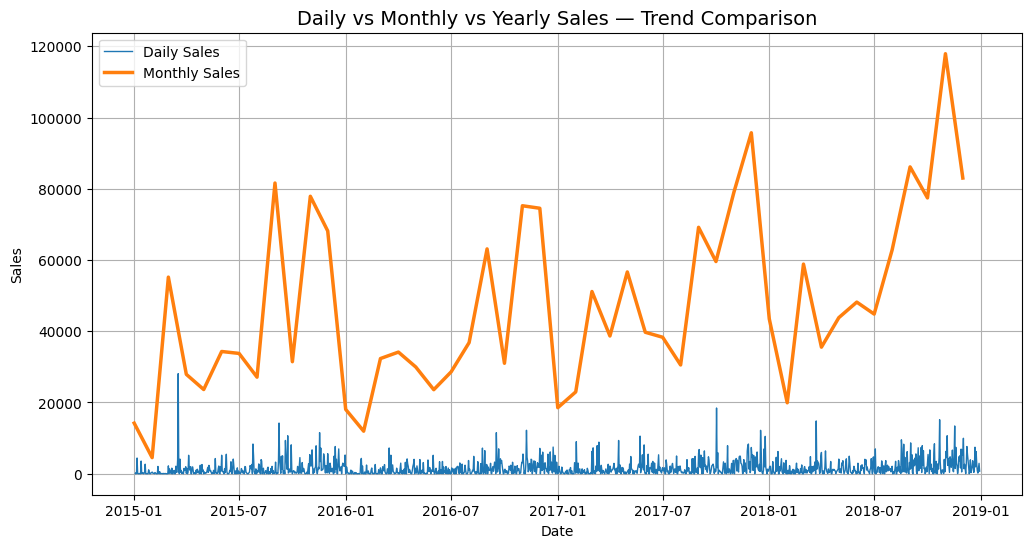

In [11]:
plt.figure(figsize=(12,6))
plt.plot(daily_sales, label='Daily Sales', linewidth=1)
plt.plot(monthly_sales, label='Monthly Sales', linewidth=2.5)
plt.title('Daily vs Monthly vs Yearly Sales — Trend Comparison', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

The above line plot shows the trend of monthly and daily sales of four years. Using this we can figure monthly data would be better for forecasting since it has less noise and shows seasonality.

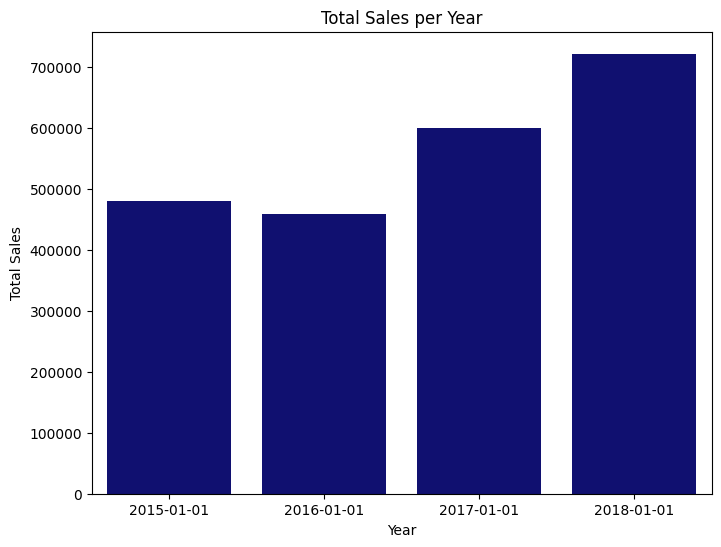

In [12]:
plt.figure(figsize=(8,6))
sns.barplot(yearly_sales, color='navy')
plt.title('Total Sales per Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.show()

The above bar chart helps us understand the total sales along the years. After 2016, the total sales is positively increasing.

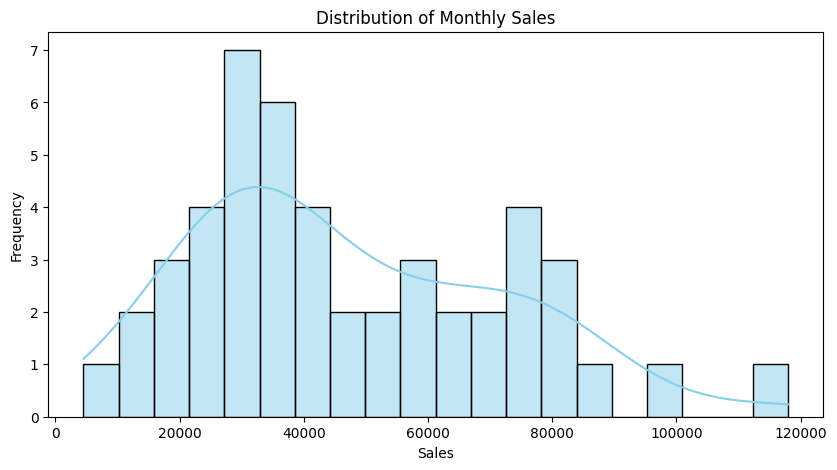

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(monthly_sales, bins=20, kde=True, color='skyblue')
plt.title('Distribution of Monthly Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

The histogram shows that the frequency of the sales is highest at the sales amount around 30000-35000.

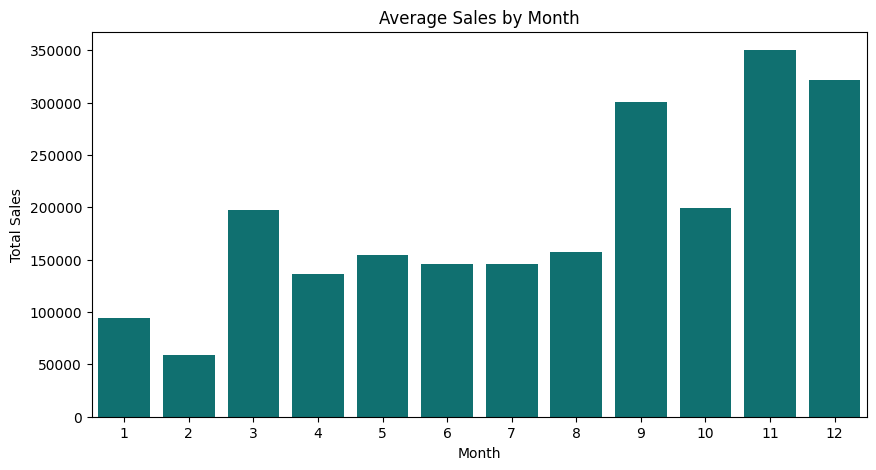

In [14]:
df_imp['Month'] = df_imp.index.month
avg_monthly_sales = df_imp.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))
sns.barplot(avg_monthly_sales, color='teal')
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

The above bar chart shows that average sales is highest at the latter half of the year near the end of the every year. With this we can assume that the prediction of the latter half will be at highest every year.

STEP 5: TIMESERIES DECOMPOSITION

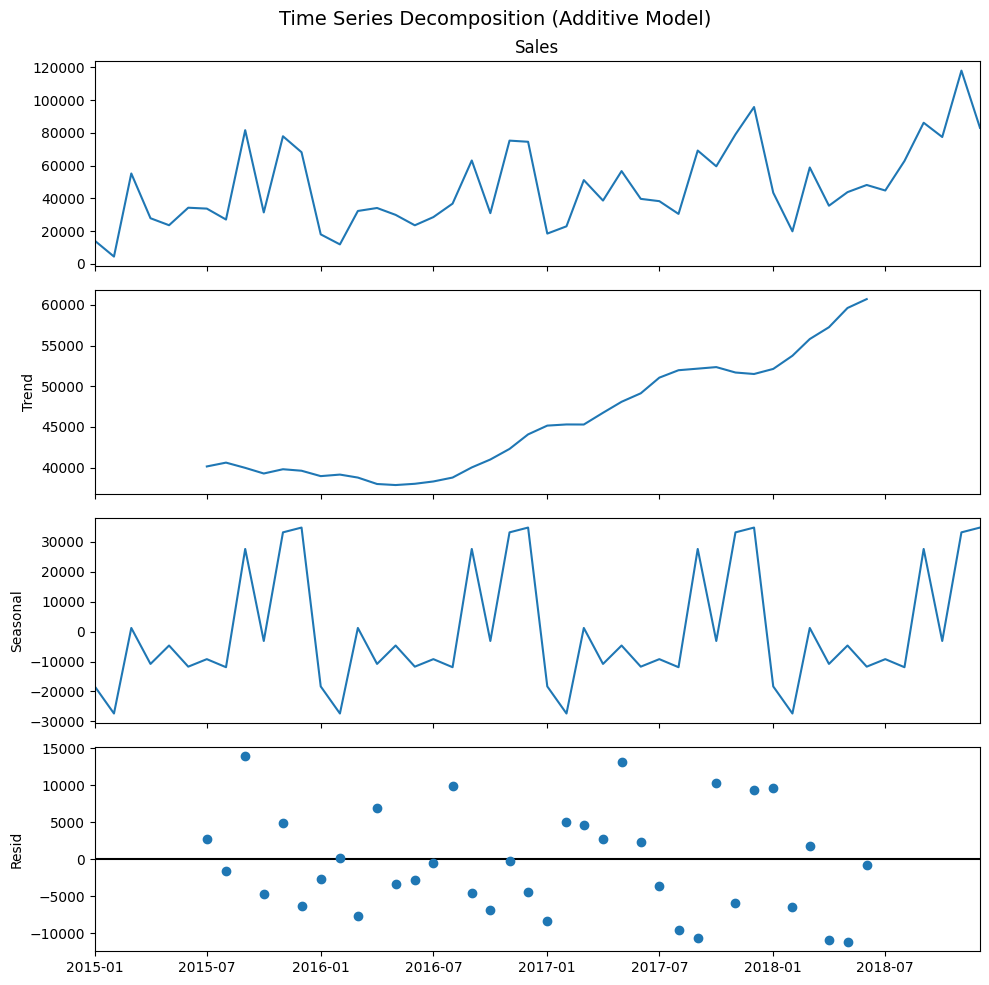

,Observed,Trend,Seasonal,Residual
Order Date,,,,
2015-01-01,14205.7070,NaN,-18307.338037,NaN
2015-02-01,4519.8920,NaN,-27368.402667,NaN
2015-03-01,55205.7970,NaN,1244.763035,NaN
2015-04-01,27906.8550,NaN,-10787.508768,NaN
2015-05-01,23644.3030,NaN,-4626.878630,NaN
2015-06-01,34322.9356,NaN,-11698.570528,NaN
2015-07-01,33781.5430,40148.902783,-9185.216915,2817.857132
2015-08-01,27117.5365,40619.434850,-11883.161587,-1618.736763
2015-09-01,81623.5268,39976.311533,27676.282185,13970.933082


In [15]:
result = seasonal_decompose(monthly_sales, model='additive', period=12)

fig = result.plot()
fig.set_size_inches(10, 10)
fig.suptitle('Time Series Decomposition (Additive Model)', fontsize=14)
plt.tight_layout()
plt.show()

decomp_df = pd.DataFrame({
    'Observed': result.observed,
    'Trend': result.trend,
    'Seasonal': result.seasonal,
    'Residual': result.resid
})
decomp_df.head(10)

The decomposition shows a clear upward trend in sales with strong seasonal patterns, indicating periodic fluctuations likely due to recurring events. The residuals are small, meaning most variations are explained by the trend and seasonality components.

STEP 6: DATA SPLITTING

Train size: 38
Test size: 10


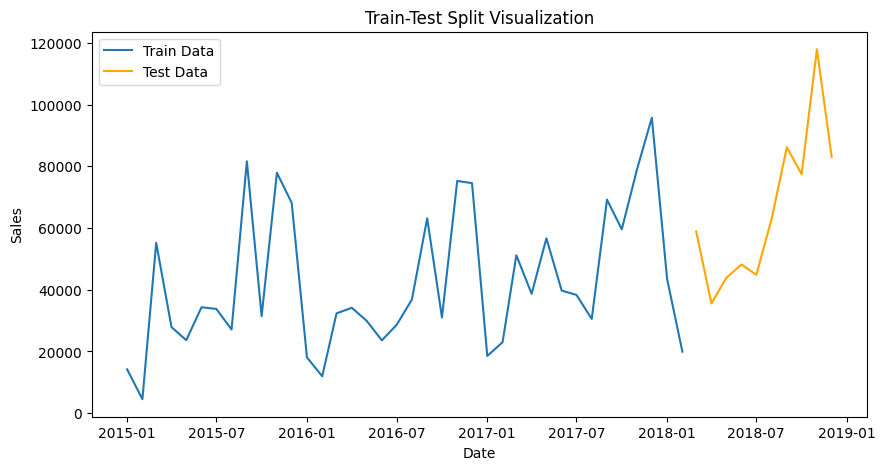

In [16]:
train_size = int(len(monthly_sales) * 0.8)
train = monthly_sales.iloc[:train_size]
test = monthly_sales.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

plt.figure(figsize=(10,5))
plt.plot(train, label='Train Data')
plt.plot(test, label='Test Data', color='orange')
plt.title('Train-Test Split Visualization')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

STEP 7: AUGUMENTED DICKEY FULLER TEST(ADF TEST)

In [17]:
adf = adfuller(train)
print("ADF Statistic:", adf[0])
print("p-value:", adf[1])

ADF Statistic: -4.147952182459003
p-value: 0.0008060981043650713


STEP 8: AUTOCORRELATION FUNCTION(ACF) AND PARTIAL AUTOCORRELATION FUNCTION(PACF)

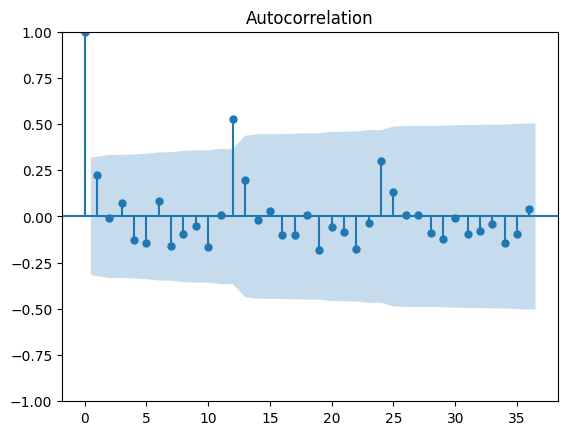

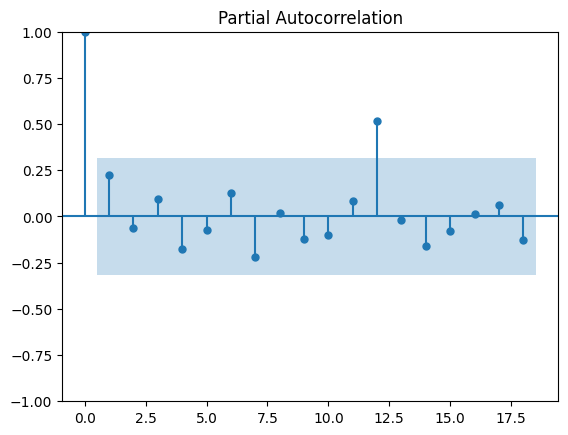

In [18]:
plot_acf(train, lags=36)
plot_pacf(train, lags=18)
plt.show()

The order(p,d,q) in ARIMA is found using acf, pacf plots where the above pacf tells us that p = 1 and acf tells us that q = 1 and here we are taking d = 1 because the model works better when degree of differencing is 1 even when the data is stationary.

STEP 9: ARIMA(AutoRegressive Integrated Moving Average) MODEL

ARIMA(1,1,1) → MAE: 22411.75, MSE: 921723561.55, RMSE: 30359.90


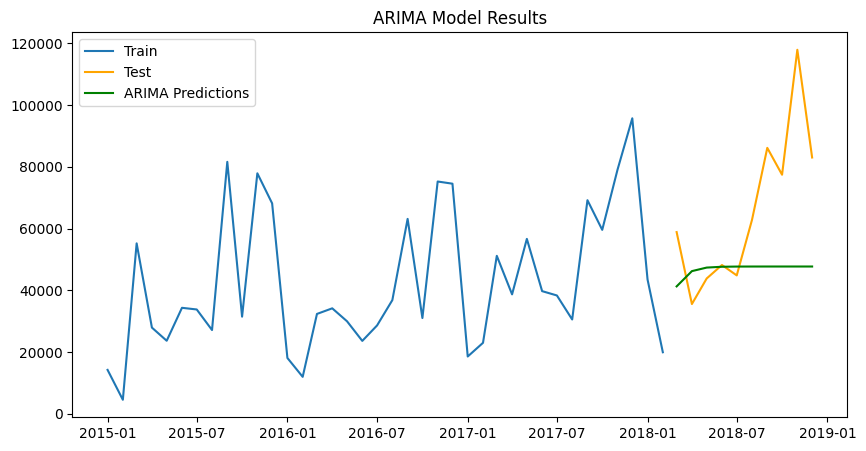

In [19]:
arima_model = ARIMA(train, order=(1,1,1))
arima_result = arima_model.fit()

arima_pred = arima_result.forecast(steps=len(test))

mae_arima = mean_absolute_error(test, arima_pred)
mse_arima = mean_squared_error(test, arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test, arima_pred))
print(f"ARIMA(1,1,1) → MAE: {mae_arima:.2f}, MSE: {mse_arima:.2f}, RMSE: {rmse_arima:.2f}")

plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='orange')
plt.plot(test.index, arima_pred, label='ARIMA Predictions', color='green')
plt.legend()
plt.title('ARIMA Model Results')
plt.show()

ARIMA model was not able to catch the pattern in the data since the data had high seasonality and has predicted mostly the mean of the data points which has lead to a very average or below average model.

STEP 10: SARIMA(Seasonal AutoRegressive Integrated Moving Average) MODEL

SARIMA(1,0,1)(1,0,1,12) → MAE: 11532.90, MSE: 191642305.29, RMSE: 13843.49


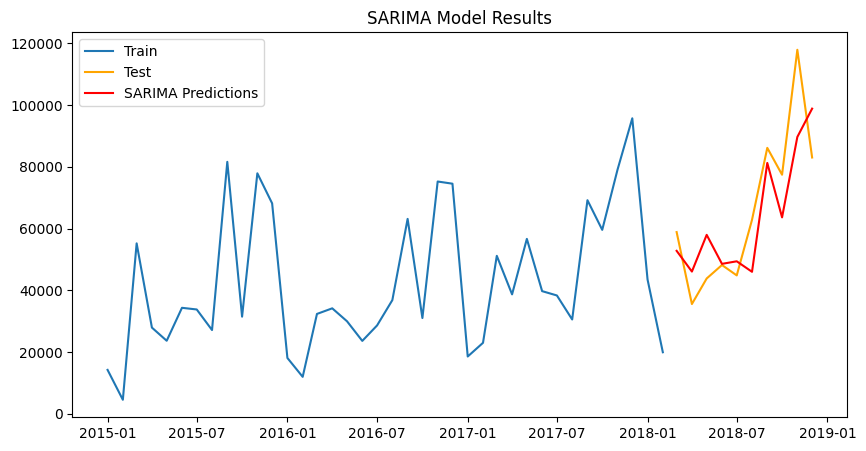

In [20]:
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_result = sarima_model.fit()

sarima_pred = sarima_result.forecast(steps=len(test))
mse_sarima = mean_squared_error(test, sarima_pred)
mae_sarima = mean_absolute_error(test, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_pred))

print(f"SARIMA(1,0,1)(1,0,1,12) → MAE: {mae_sarima:.2f}, MSE: {mse_sarima:.2f}, RMSE: {rmse_sarima:.2f}")

plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='orange')
plt.plot(test.index, sarima_pred, label='SARIMA Predictions', color='red')
plt.legend()
plt.title('SARIMA Model Results')
plt.show()

SARIMA model works best with seasonal data. Since our data was seasonal so this model performed well for catching patterns in the data. Although not perfect this model has attained better prediction compared to ARIMA.

STEP 11: PROPHET MODEL

09:39:42 - cmdstanpy - INFO - Chain [1] start processing
09:39:43 - cmdstanpy - INFO - Chain [1] done processing


Prophet → MAE: 9988.63,MSE: 218815327.55, RMSE: 14792.41


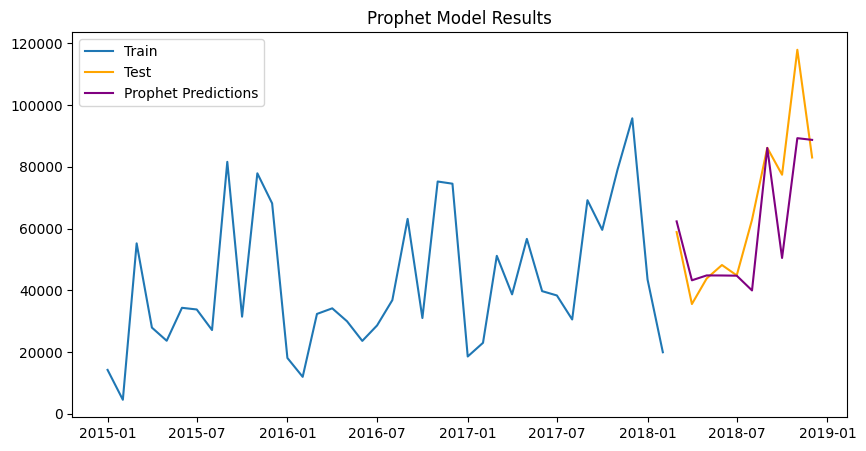

In [21]:
prophet_df = monthly_sales.reset_index()
prophet_df.columns = ['ds', 'y']

train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

prophet_model = Prophet()
prophet_model.fit(train_prophet)

future = test_prophet[['ds']]
forecast = prophet_model.predict(future)

mae_prophet = mean_absolute_error(test_prophet['y'], forecast['yhat'])
mse_prophet = mean_squared_error(test_prophet['y'], forecast['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'], forecast['yhat']))

print(f"Prophet → MAE: {mae_prophet:.2f},MSE: {mse_prophet:.2f}, RMSE: {rmse_prophet:.2f}")

plt.figure(figsize=(10,5))
plt.plot(train_prophet['ds'], train_prophet['y'], label='Train')
plt.plot(test_prophet['ds'], test_prophet['y'], label='Test', color='orange')
plt.plot(forecast['ds'], forecast['yhat'], label='Prophet Predictions', color='purple')
plt.legend()
plt.title('Prophet Model Results')
plt.show()

Prophet model worked the best even when no parameters were setup manually for trends or seasonality. It learnt the pattern on its own. Even though RMSE of prophet is a bit higher than SARIMA, prophet performs as good as SARIMA. Prophet made less small errors compared to SARIMA.

STEP 12: MODEL EVALUATION (ALL THREE MODEL EVALUATION COMPARISON)

In [22]:
evaluation = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA', 'Prophet'],
    'MAE': [mae_arima, mae_sarima, mae_prophet],
    'MSE': [mse_arima, mse_sarima, mse_prophet],
    'RMSE': [rmse_arima, rmse_sarima, rmse_prophet]
})

print("Model Performance Comparison:")
display(evaluation.sort_values(by='RMSE'))


Model Performance Comparison:


,Model,MAE,MSE,RMSE
1,SARIMA,11532.900692,1.916423e+08,13843.493247
2,Prophet,9988.634795,2.188153e+08,14792.407767
0,ARIMA,22411.753327,9.217236e+08,30359.900552


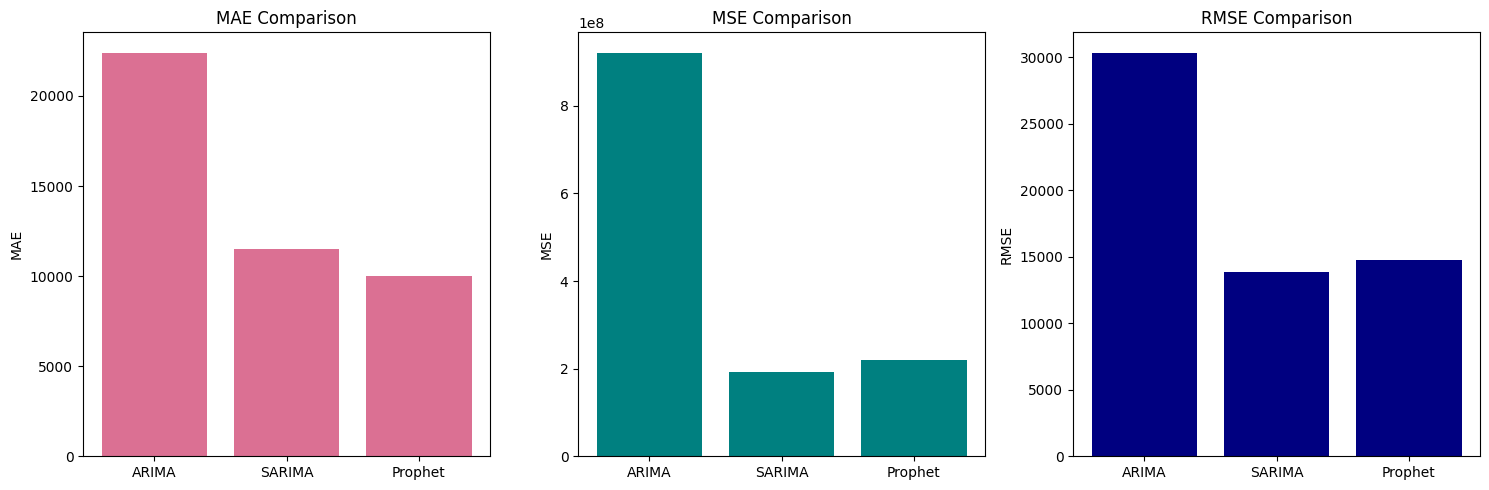

In [23]:
plt.figure(figsize=(15,5)) 

# MAE
plt.subplot(1,3,1)
plt.bar(evaluation['Model'], evaluation['MAE'], color='palevioletred') 
plt.title('MAE Comparison') 
plt.ylabel('MAE')

# MSE
plt.subplot(1,3,2)
plt.bar(evaluation['Model'], evaluation['MSE'], color='teal')
plt.title('MSE Comparison')
plt.ylabel('MSE')

# RMSE 
plt.subplot(1,3,3)
plt.bar(evaluation['Model'], evaluation['RMSE'], color='navy')
plt.title('RMSE Comparison')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()


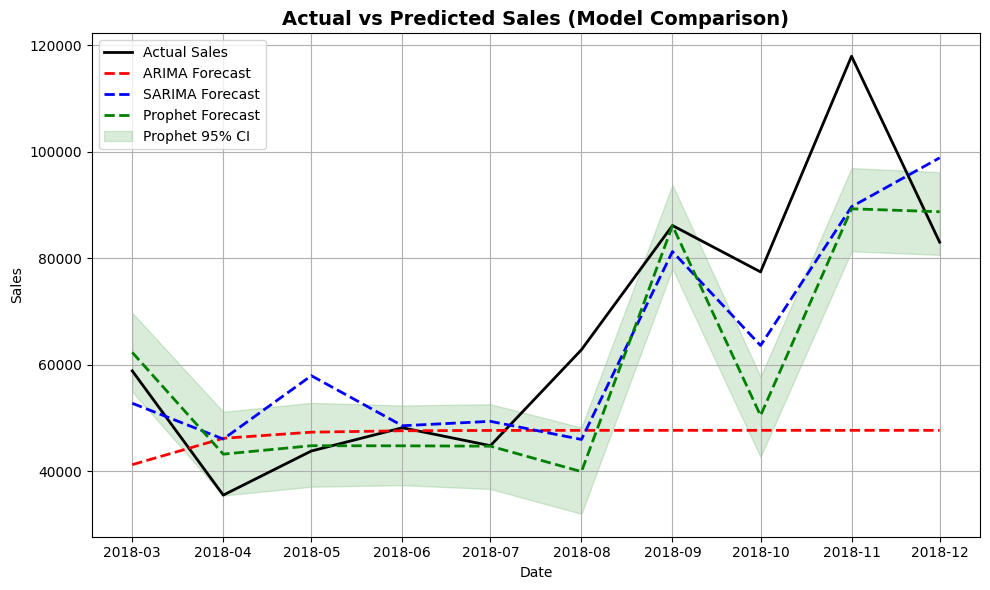

In [24]:
plt.figure(figsize=(10, 6))

# Actual values
plt.plot(test.index, test, color='black', label='Actual Sales', linewidth=2)

# Model forecasts
plt.plot(test.index, arima_pred, color='red', linestyle='--', label='ARIMA Forecast', linewidth=2)
plt.plot(test.index, sarima_pred, color='blue', linestyle='--', label='SARIMA Forecast', linewidth=2)
plt.plot(forecast['ds'], forecast['yhat'], color='green', linestyle='--', label='Prophet Forecast', linewidth=2)

# Prophet confidence interval
plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    color='green', alpha=0.15, label='Prophet 95% CI'
)

# Title and labels
plt.title('Actual vs Predicted Sales (Model Comparison)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()